In [0]:
# Initialisation de Spark (Databricks)
# Vérifie que la session Spark est bien active
spark

# Affiche la version de Spark utilisée
print("Spark version :", spark.version)

Spark version : 4.1.0


In [0]:
# Chargement du dataset Steam depuis le bucket S3 JEDHA
# multiLine=True permet de lire un JSON imbriqué sur plusieurs lignes
df = spark.read.option("multiLine", True).json("s3://full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json")

In [0]:
# Dimensions du dataset
row_count = df.count()          # Nombre de lignes (jeux)
column_count = len(df.columns)  # Nombre de colonnes

print(f"Le DataFrame contient {row_count} lignes et {column_count} colonnes.")

The DataFrame has 55691 rows and 2 columns.


In [0]:
# Affichage du schéma pour comprendre la structure imbriquée du JSON
df.printSchema()

root
 |-- data: struct (nullable = true)
 |    |-- appid: long (nullable = true)
 |    |-- categories: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- ccu: long (nullable = true)
 |    |-- developer: string (nullable = true)
 |    |-- discount: string (nullable = true)
 |    |-- genre: string (nullable = true)
 |    |-- header_image: string (nullable = true)
 |    |-- initialprice: string (nullable = true)
 |    |-- languages: string (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- negative: long (nullable = true)
 |    |-- owners: string (nullable = true)
 |    |-- platforms: struct (nullable = true)
 |    |    |-- linux: boolean (nullable = true)
 |    |    |-- mac: boolean (nullable = true)
 |    |    |-- windows: boolean (nullable = true)
 |    |-- positive: long (nullable = true)
 |    |-- price: string (nullable = true)
 |    |-- publisher: string (nullable = true)
 |    |-- release_date: string (nullable = true)
 |    |-

Ce dataset Steam est un JSON semi-structuré contenant des informations sur les jeux (éditeur, prix, avis, plateformes, tags).

## Analyse au niveau macro

Analyse globale du marché :  
nombre de jeux par éditeur, évaluations, réductions, évolution des sorties dans le temps, etc.

## Quel éditeur a publié le plus de jeux sur Steam ?

In [0]:
# Aplatissement de la structure JSON : accès aux champs de data.*
df_flat = df.select("data.*")

# Regroupement par éditeur et comptage du nombre de jeux
publisher_counts = df_flat.groupBy("publisher").count()

# Tri décroissant pour trouver les éditeurs les plus prolifiques
publisher_counts_sorted = publisher_counts.orderBy("count", ascending=False)

# Affichage du top 10
publisher_counts_sorted.show(10, truncate=False)

+---------------+-----+
|publisher      |count|
+---------------+-----+
|Big Fish Games |422  |
|8floor         |202  |
|SEGA           |165  |
|Strategy First |151  |
|Square Enix    |141  |
|Choice of Games|140  |
|               |132  |
|Sekai Project  |132  |
|HH-Games       |132  |
|Ubisoft        |127  |
+---------------+-----+
only showing top 10 rows


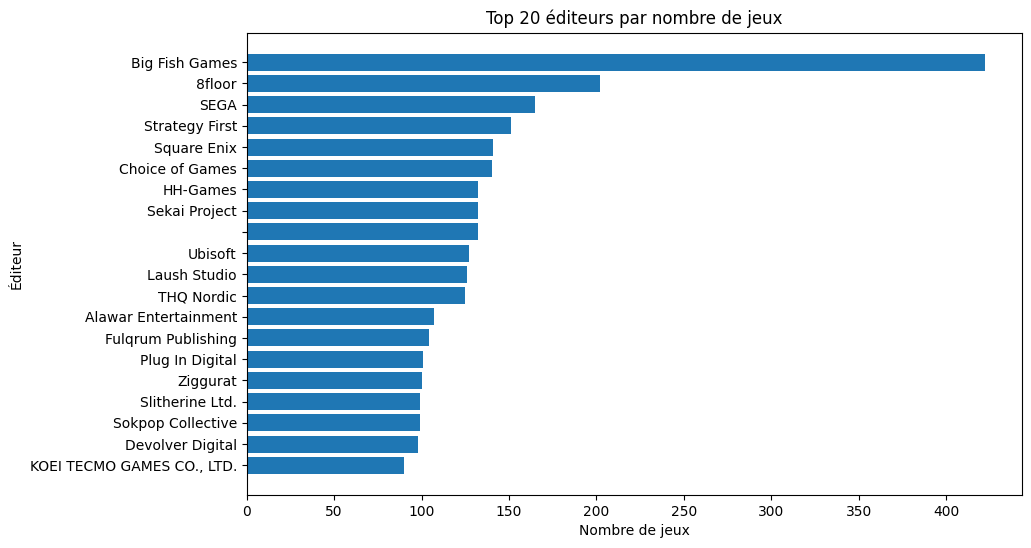

In [0]:
# Conversion en Pandas pour la visualisation matplotlib
top20_pub = publisher_counts_sorted.limit(20).toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top20_pub["publisher"], top20_pub["count"])
plt.gca().invert_yaxis()  # Éditeur le plus prolifique en haut
plt.title("Top 20 éditeurs par nombre de jeux")
plt.xlabel("Nombre de jeux")
plt.ylabel("Éditeur")
plt.show()

Les résultats montrent que certains éditeurs dominent largement le catalogue Steam.  
Big Fish Games est l'éditeur ayant publié le plus grand nombre de jeux (422 titres), suivi par 8floor et SEGA.  
On observe également la présence d'éditeurs majeurs comme Square Enix et Ubisoft, ainsi que des éditeurs spécialisés ou indépendants très prolifiques.  
La ligne vide suggère la présence de données manquantes ou mal renseignées pour certains jeux.

## Quels sont les jeux les mieux notés ?

In [0]:
from pyspark.sql.functions import col

df_flat = df.select("data.*")

# Filtre : on garde uniquement les jeux avec au moins 100 avis (ratio fiable)
df_filtered = df_flat.filter((col("positive") + col("negative") >= 100))

# Calcul du total d'avis et du ratio d'avis positifs
df_with_rating = df_filtered.withColumn(
    "total_reviews", col("positive") + col("negative")
).withColumn(
    "positive_ratio", col("positive") / col("total_reviews")
)

# Sélection et tri par ratio décroissant, puis par volume d'avis
df_best_rated = df_with_rating.select(
    "name", "positive", "negative", "total_reviews", "positive_ratio"
).orderBy(
    col("positive_ratio").desc(),
    col("total_reviews").desc()
)

df_best_rated.show(10, truncate=False)

+-------------------------------------------------+--------+--------+-------------+--------------+
|name                                             |positive|negative|total_reviews|positive_ratio|
+-------------------------------------------------+--------+--------+-------------+--------------+
|The Void Rains Upon Her Heart                    |496     |0       |496          |1.0           |
|祈風 Inorikaze                                   |327     |0       |327          |1.0           |
|秘封旅行 ~ Secret Sealing Travel                 |218     |0       |218          |1.0           |
|Elasto Mania Remastered                          |190     |0       |190          |1.0           |
|Freshly Frosted                                  |157     |0       |157          |1.0           |
|HAYAI                                            |148     |0       |148          |1.0           |
|FIND ALL 2: Middle Ages                          |132     |0       |132          |1.0           |
|Touhou Kaeizuka

Les jeux les mieux classés affichent un ratio d'avis positifs de 100 %, sans aucun avis négatif.  

Cependant, leur volume total d'avis reste relativement faible (100 à 500 avis), ce qui peut biaiser le classement.  
Un ratio simple favorise donc les jeux de niche par rapport aux titres très populaires ayant un grand nombre d'évaluations.

## Y a-t-il des années avec plus de sorties ? Y a-t-il eu plus ou moins de jeux publiés pendant le Covid ?

In [0]:
# Détection du format des dates pour choisir la bonne méthode d'extraction
df.select("data.release_date").distinct().show(3, truncate=False)

+------------+
|release_date|
+------------+
|2019/12/17  |
|2019/03/21  |
|2019/03/9   |
+------------+
only showing top 3 rows


In [0]:
from pyspark.sql.functions import col, regexp_extract

df_flat = df.select("data.*")

# Extraction de l'année avec une regex (4 chiffres consécutifs)
# Regroupement par année et comptage des sorties
df_releases_by_year = (
    df_flat
    .withColumn("release_year",
                regexp_extract(col("release_date"), r"(\d{4})", 1))
    .filter(col("release_year") != "")   # Supprime les dates mal formatées
    .groupBy("release_year")
    .count()
    .orderBy("release_year")
)

df_releases_by_year.display()

release_year,count
1997,2
1998,1
1999,3
2000,2
2001,4
2002,1
2003,3
2004,6
2005,6
2006,61


In [0]:
from pyspark.sql.functions import col, regexp_extract

df_flat = df.select("data.*")

# Même analyse affichée via display() pour la visualisation Databricks
df_releases_by_year = (
    df_flat
    .withColumn("release_year",
                regexp_extract(col("release_date"), r"(\d{4})", 1))
    .filter(col("release_year") != "")
    .groupBy("release_year")
    .count()
    .orderBy("release_year")
)

df_releases_by_year.display()

release_year,count
1997,2
1998,1
1999,3
2000,2
2001,4
2002,1
2003,3
2004,6
2005,6
2006,61


In [0]:
from pyspark.sql.functions import regexp_extract, max, col

# Récupération de l'année de sortie la plus récente dans le dataset
df_latest_year = (
    df_flat
    .withColumn("release_year",
                regexp_extract(col("release_date"), r"(\d{4})", 1))
    .filter(col("release_year") != "")
    .agg(max("release_year").alias("annee_derniere_sortie"))
)

df_latest_year.show()

+-------------------+
|latest_release_year|
+-------------------+
|               2022|
+-------------------+



Le nombre de sorties de jeux sur Steam a connu une forte accélération entre 2013 et 2018. Cette période a été suivie d'une stabilisation en 2019 et 2020, puis d'une nouvelle hausse à partir de 2021. Bien que les données pour 2022 soient incomplètes (la dernière sortie enregistrée datant du 11 novembre), on peut raisonnablement estimer que l'année atteindra environ 9 000 sorties, sur la base des 7 200 jeux publiés à cette date.

## Comment les prix sont-ils distribués ? Y a-t-il beaucoup de jeux en promotion ?

In [0]:
from pyspark.sql.functions import col, regexp_replace

df_flat = df.select("data.*")

# Suppression des prix nuls ou vides
df_prices = df_flat.filter((col("price").isNotNull()) & (col("price") != ""))

# Nettoyage : remplacement de la virgule par un point, conversion en float
df_prices_clean = df_prices.withColumn("price_float", regexp_replace("price", ",", ".").cast("float"))

# Création de tranches de prix par pas de 5€
df_prices_binned = df_prices_clean.withColumn("price_bin", (col("price_float") / 5).cast("int") * 5)

# Distribution du nombre de jeux par tranche de prix
df_price_distribution = df_prices_binned.groupBy("price_bin").count().orderBy("price_bin")
df_price_distribution.show()

+---------+-----+
|price_bin|count|
+---------+-----+
|        0| 7780|
|       25|   31|
|       30|    8|
|       35|   33|
|       40|   11|
|       45|  305|
|       50|  102|
|       55|  102|
|       60|    6|
|       65|   41|
|       70|   35|
|       75|   47|
|       80|    8|
|       85|   25|
|       90|   36|
|       95| 5245|
|      100|   26|
|      105|    6|
|      110|    1|
|      115|   40|
+---------+-----+
only showing top 20 rows


In [0]:
# Analyse des remises : distribution des valeurs de réduction
df.select("data.discount") \
  .groupBy("discount") \
  .count() \
  .orderBy(col("count").desc()) \
  .show(20, truncate=False)

+--------+-----+
|discount|count|
+--------+-----+
|0       |53173|
|50      |350  |
|90      |239  |
|80      |228  |
|75      |223  |
|40      |164  |
|51      |146  |
|60      |137  |
|70      |137  |
|30      |131  |
|20      |112  |
|25      |85   |
|10      |53   |
|15      |45   |
|35      |39   |
|65      |37   |
|87      |36   |
|85      |34   |
|83      |26   |
|48      |25   |
+--------+-----+
only showing top 20 rows


In [0]:
from pyspark.sql.functions import col

# Nombre total de jeux dans le dataset
total_games = df.select("data.*").count()

# Jeux avec une vraie remise (discount différent de 0)
discounted_games = df.select("data.discount") \
    .filter((col("discount").isNotNull()) & (col("discount") != "") & (col("discount") != "0")) \
    .count()

# Affichage du ratio
print(f"{discounted_games} jeux sur {total_games} ont une remise active.")
print(f"{(discounted_games / total_games) * 100:.2f}% des jeux sont en promotion.")

2518 out of 55691 games have a real discount.
4.52% of games are discounted.


## Quelles sont les langues les plus représentées ?

In [0]:
from pyspark.sql.functions import col, split, explode, trim

df_flat = df.select("data.*")

# Suppression des valeurs nulles ou vides
df_lang = df_flat.filter((col("languages").isNotNull()) & (col("languages") != ""))

# Découpage de la chaîne de langues séparées par des virgules
df_lang_split = df_lang.withColumn("language", explode(split(col("languages"), ",")))

# Nettoyage des espaces (ex : " French" → "French")
df_lang_trimmed = df_lang_split.withColumn("language", trim(col("language")))

# Comptage par langue, tri décroissant
df_language_counts = df_lang_trimmed.groupBy("language").count().orderBy(col("count").desc())

In [0]:
# Affichage Databricks du top 20 des langues
df_language_top20 = df_language_counts.limit(20)
display(df_language_top20)

language,count
English,55116
German,14019
French,13426
Russian,12922
Simplified Chinese,12782
Spanish - Spain,12233
Japanese,10368
Italian,9304
Portuguese - Brazil,6750
Korean,6600


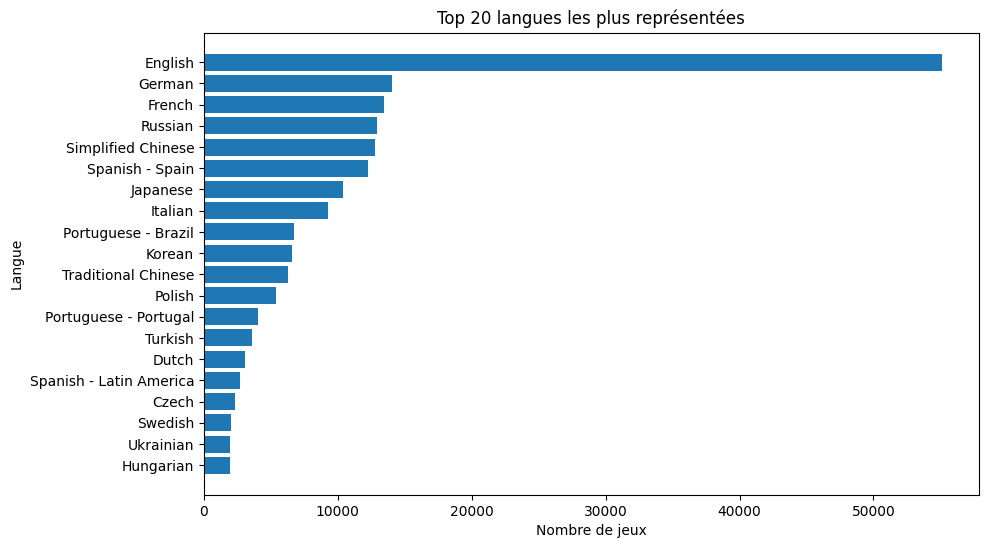

In [0]:
# Visualisation matplotlib du top 20 des langues
pdf_lang = df_language_top20.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(pdf_lang["language"], pdf_lang["count"])
plt.gca().invert_yaxis()  # Langue la plus représentée en haut
plt.title("Top 20 langues les plus représentées")
plt.xlabel("Nombre de jeux")
plt.ylabel("Langue")
plt.show()

L'anglais domine largement comme langue principale, ce qui témoigne de son importance pour la communication à l'échelle mondiale. Parmi les autres langues importantes figurent l'allemand, le français, le russe, le chinois, l'espagnol, le japonais et l'italien.

## Y a-t-il beaucoup de jeux interdits aux moins de 16/18 ans ?

In [0]:
from pyspark.sql.functions import col, regexp_extract, when

# Extraction de l'âge requis sous forme entière depuis le champ texte
df2 = df.withColumn(
    "required_age_int",
    when(
        regexp_extract(col("data.required_age"), r"\d+", 0) != "",
        regexp_extract(col("data.required_age"), r"\d+", 0).cast("int")
    ).otherwise(None)
)

# Comptage des jeux 16+ et 18+ séparément
count_16 = df2.filter(col("required_age_int") == 16).count()
count_18 = df2.filter(col("required_age_int") == 18).count()

# Total et pourcentage
total_16_18 = count_16 + count_18
total_jeux = df2.count()
pourcentage_16_18 = (total_16_18 / total_jeux) * 100

print("Nombre de jeux 16+ :", count_16)
print("Nombre de jeux 18+ :", count_18)
print("Total jeux 16+ et 18+ :", total_16_18)
print("Pourcentage 16+ et 18+ : {:.2f}%".format(pourcentage_16_18))

Nombre de jeux 16+ : 38
Nombre de jeux 18+ : 223
Total jeux 16+ et 18+ : 261
Pourcentage 16+ et 18+ : 0.47%


Sur 55 691 jeux analysés, seuls 261 titres nécessitent un âge minimum de 16 ans ou plus, soit 0,47 % du catalogue total.

Cela montre que les jeux à restriction d'âge élevée (16+ et 18+) représentent une part extrêmement marginale du marché Steam dans ce dataset, largement dominé par des jeux sans limite d'âge.

## Analyse par genre
Quels sont les genres les plus courants et lesquels fonctionnent le mieux ?

## Quels sont les genres les plus représentés ?

In [0]:
from pyspark.sql.functions import col, split, explode, trim

df_flat = df.select("data.*")

# Suppression des jeux sans genre renseigné
df_genre = df_flat.filter((col("genre").isNotNull()) & (col("genre") != ""))

# Découpage des genres séparés par des virgules (un jeu peut avoir plusieurs genres)
df_genre_split = df_genre.withColumn("genre_indiv", explode(split(col("genre"), ",")))

# Nettoyage des espaces
df_genre_trimmed = df_genre_split.withColumn("genre_indiv", trim(col("genre_indiv")))

# Comptage et tri décroissant
df_genre_counts = df_genre_trimmed.groupBy("genre_indiv").count().orderBy(col("count").desc())

df_genre_counts.show(20, truncate=False)

+---------------------+-----+
|genre_indiv          |count|
+---------------------+-----+
|Indie                |39681|
|Action               |23759|
|Casual               |22086|
|Adventure            |21431|
|Strategy             |10895|
|Simulation           |10836|
|RPG                  |9534 |
|Early Access         |6145 |
|Free to Play         |3393 |
|Sports               |2666 |
|Racing               |2155 |
|Massively Multiplayer|1460 |
|Utilities            |682  |
|Design & Illustration|406  |
|Animation & Modeling |322  |
|Education            |317  |
|Video Production     |247  |
|Audio Production     |195  |
|Violent              |168  |
|Software Training    |164  |
+---------------------+-----+
only showing top 20 rows


In [0]:
# Affichage Databricks du top 20 des genres
df_genre_top20 = df_genre_counts.limit(20)
display(df_genre_top20)

genre_indiv,count
Indie,39681
Action,23759
Casual,22086
Adventure,21431
Strategy,10895
Simulation,10836
RPG,9534
Early Access,6145
Free to Play,3393
Sports,2666


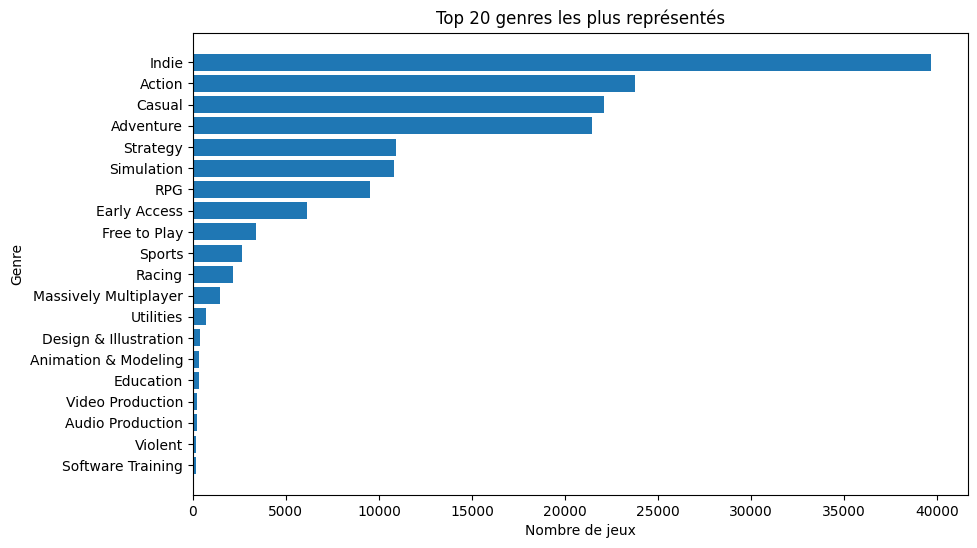

In [0]:
# Visualisation matplotlib du top 20 des genres
pdf_genre = df_genre_top20.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(pdf_genre["genre_indiv"], pdf_genre["count"])
plt.gca().invert_yaxis()  # Genre le plus représenté en haut
plt.title("Top 20 genres les plus représentés")
plt.xlabel("Nombre de jeux")
plt.ylabel("Genre")
plt.show()

Le genre Indie domine très largement le dataset avec 39 681 jeux, ce qui en fait la catégorie la plus représentée. Il est suivi par Action (23 759), Casual (22 086) et Adventure (21 431), montrant une forte présence de jeux accessibles et orientés divertissement grand public.

Les genres Strategy (10 895), Simulation (10 836) et RPG (9 534) constituent un second bloc important, traduisant un intérêt marqué pour des expériences plus complexes ou immersives. À l'inverse, des catégories comme Massively Multiplayer, Utilities ou Animation & Modeling restent très minoritaires.

## Existe-t-il des genres qui présentent un meilleur ratio d'avis positifs/négatifs ?

In [0]:
from pyspark.sql.functions import col, split, explode, trim

# Aplatissement et explosion des genres
df_flat = df.select("data.*")
df_genre = df_flat.filter((col("genre").isNotNull()) & (col("genre") != ""))
df_genre_split = df_genre.withColumn("genre_indiv", explode(split(col("genre"), ",")))
df_genre_trimmed = df_genre_split.withColumn("genre_indiv", trim(col("genre_indiv")))

# Filtre : minimum 100 avis pour avoir un ratio fiable
df_genre_filtered = df_genre_trimmed.filter((col("positive") + col("negative") >= 100))

# Calcul du ratio d'avis positifs par jeu
df_with_ratio = df_genre_filtered.withColumn(
    "positive_ratio", col("positive") / (col("positive") + col("negative"))
)

# Moyenne du ratio par genre, tri décroissant
df_genre_ratio = df_with_ratio.groupBy("genre_indiv") \
    .avg("positive_ratio") \
    .withColumnRenamed("avg(positive_ratio)", "ratio_moyen_positif") \
    .orderBy(col("ratio_moyen_positif").desc())

df_genre_ratio.show(20, truncate=False)

+---------------------+------------------+
|genre_indiv          |avg_positive_ratio|
+---------------------+------------------+
|Game Development     |0.8257796145431594|
|Photo Editing        |0.8257165714669726|
|Web Publishing       |0.8191462394287768|
|Animation & Modeling |0.8103836893346357|
|Design & Illustration|0.8075536507255923|
|Sexual Content       |0.7976123117943439|
|Casual               |0.7970813855549078|
|Adventure            |0.7933820876944823|
|Indie                |0.7912639639445219|
|Utilities            |0.7830347853549947|
|Education            |0.7766577818501059|
|RPG                  |0.7748140155339491|
|Action               |0.7703330892964919|
|Nudity               |0.7667803236716946|
|Simulation           |0.7607264997787848|
|Software Training    |0.7601382989967299|
|Strategy             |0.7589381699262258|
|Sports               |0.7548743299612206|
|Racing               |0.7547281732445806|
|Video Production     |0.7547101987662453|
+----------

In [0]:
# Visualisation Databricks du ratio d'avis positifs par genre
display(df_genre_ratio.limit(20))

genre_indiv,avg_positive_ratio
Game Development,0.8257796145431594
Photo Editing,0.8257165714669726
Web Publishing,0.8191462394287768
Animation & Modeling,0.8103836893346357
Design & Illustration,0.8075536507255923
Sexual Content,0.7976123117943439
Casual,0.7970813855549078
Adventure,0.7933820876944823
Indie,0.7912639639445219
Utilities,0.7830347853549947


Les taux moyens d'avis positifs sont relativement similaires tous genres confondus, sans qu'aucune catégorie ne se démarque significativement. Cela suggère que la satisfaction des joueurs est assez constante pour différents types de jeux, quel que soit le genre.

## Certains éditeurs ont-ils des genres de prédilection ?

In [0]:
from pyspark.sql.functions import col, split, explode, trim

# Aplatissement et explosion des genres
df_flat = df.select("data.*")
df_genre = df_flat.filter((col("genre").isNotNull()) & (col("genre") != ""))
df_genre_split = df_genre.withColumn("genre_indiv", explode(split(col("genre"), ",")))
df_genre_trimmed = df_genre_split.withColumn("genre_indiv", trim(col("genre_indiv")))

# Suppression des éditeurs non renseignés
df_publisher_genre = df_genre_trimmed.filter((col("publisher").isNotNull()) & (col("publisher") != ""))

# Comptage des jeux par couple (éditeur, genre)
df_publisher_pref = df_publisher_genre.groupBy("publisher", "genre_indiv").count()

# Tri par éditeur puis par nombre décroissant
df_publisher_pref_sorted = df_publisher_pref.orderBy("publisher", col("count").desc())

df_publisher_pref_sorted.show(20, truncate=False)

+-----------------------------+------------+-----+
|publisher                    |genre_indiv |count|
+-----------------------------+------------+-----+
|                             |Indie       |2    |
|                             |Action      |2    |
|                             |Casual      |1    |
| AK Studio                   |Indie       |2    |
| AK Studio                   |Casual      |1    |
| AK Studio                   |Action      |1    |
| AK Studio                   |Adventure   |1    |
| AK Studio                   |Racing      |1    |
| ARVORE Immersive Experiences|Strategy    |1    |
| ARVORE Immersive Experiences|Adventure   |1    |
| ARVORE Immersive Experiences|Casual      |1    |
| ARVORE Immersive Experiences|Indie       |1    |
| ARVORE Immersive Experiences|Action      |1    |
| Alon Zubina                 |Indie       |1    |
| Alon Zubina                 |Simulation  |1    |
| Alon Zubina                 |Adventure   |1    |
| Appnori Inc.                |

In [0]:
from pyspark.sql.functions import col

# Sélection des 20 éditeurs les plus prolifiques
top_publishers = df_flat.filter((col("publisher").isNotNull()) & (col("publisher") != "")) \
    .groupBy("publisher") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(20) \
    .select("publisher")

# Sélection des 20 genres les plus représentés
top_genres = df_genre_trimmed.groupBy("genre_indiv") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(20) \
    .select("genre_indiv")

# Jointure pour ne garder que les combinaisons top éditeurs × top genres
df_heatmap_base = df_publisher_genre \
    .join(top_publishers, on="publisher") \
    .join(top_genres, on="genre_indiv")

# Comptage des jeux par couple (éditeur, genre)
df_heatmap = df_heatmap_base.groupBy("publisher", "genre_indiv").count()

In [0]:
# Conversion du count en entier pour l'affichage Databricks (heatmap)
df_heatmap_fixed = df_heatmap.select(
    col("publisher"),
    col("genre_indiv"),
    col("count").cast("int").alias("count")
)

In [0]:
# Affichage Databricks : heatmap éditeurs × genres
display(df_heatmap_fixed)

publisher,genre_indiv,count
HH-Games,Action,38
Big Fish Games,Casual,418
Strategy First,Action,28
"KOEI TECMO GAMES CO., LTD.",Action,25
Ziggurat,Sports,11
HH-Games,Sports,1
Laush Studio,Action,20
Reforged Group,Casual,11
Laush Studio,Racing,5
Ziggurat,Indie,2


La heatmap montre que la publication des jeux est fortement concentrée dans quelques genres dominants, notamment Indie, Action et Casual, qui représentent la majorité du catalogue. À l'inverse, plusieurs catégories apparaissent faiblement représentées, illustrant une structure de marché déséquilibrée avec une forte concentration sur certains segments populaires.

## Quels sont les genres les plus lucratifs ?

In [0]:
from pyspark.sql.functions import col, split, explode, trim, regexp_replace

# Étape 1 : Aplatissement et explosion des genres
df_flat = df.select("data.*")
df_genre = df_flat.filter((col("genre").isNotNull()) & (col("genre") != ""))
df_genre_split = df_genre.withColumn("genre_indiv", explode(split(col("genre"), ",")))
df_genre_trimmed = df_genre_split.withColumn("genre_indiv", trim(col("genre_indiv")))

# Étape 2 : Nettoyage du prix et conversion en float
df_with_price = df_genre_trimmed \
    .filter((col("price").isNotNull()) & (col("price") != "")) \
    .withColumn("price_float", regexp_replace("price", ",", ".").cast("float"))

# Étape 3 : Estimation du revenu = prix × nombre total d'avis (proxy d'engagement)
df_with_revenue = df_with_price.withColumn(
    "revenu_estime", col("price_float") * (col("positive") + col("negative"))
)

# Étape 4 : Agrégation par genre, tri décroissant
df_genre_revenue = df_with_revenue.groupBy("genre_indiv") \
    .sum("revenu_estime") \
    .withColumnRenamed("sum(revenu_estime)", "revenu_total_estime") \
    .orderBy(col("revenu_total_estime").desc())

df_genre_revenue.show(20, truncate=False)

+---------------------+-----------------------+
|genre_indiv          |total_estimated_revenue|
+---------------------+-----------------------+
|Action               |1.05306097551E11       |
|Adventure            |6.782266358E10         |
|Indie                |5.0648939283E10        |
|RPG                  |4.92395177E10          |
|Simulation           |3.4066895559E10        |
|Strategy             |3.0288584895E10        |
|Massively Multiplayer|1.1609725801E10        |
|Casual               |1.0335681222E10        |
|Early Access         |8.75185276E9           |
|Sports               |5.755989868E9          |
|Racing               |5.479090035E9          |
|Design & Illustration|4.43423183E8           |
|Utilities            |4.38251854E8           |
|Animation & Modeling |3.63198884E8           |
|Photo Editing        |2.85662995E8           |
|Audio Production     |1.37771562E8           |
|Video Production     |1.27914887E8           |
|Web Publishing       |1.22858029E8     

In [0]:
# Visualisation Databricks des genres les plus lucratifs
display(df_genre_revenue.limit(20))

genre_indiv,total_estimated_revenue
Action,1.05306097551E11
Adventure,6.782266358E10
Indie,5.0648939283E10
RPG,4.92395177E10
Simulation,3.4066895559E10
Strategy,3.0288584895E10
Massively Multiplayer,1.1609725801E10
Casual,1.0335681222E10
Early Access,8.75185276E9
Sports,5.755989868E9


D'après une estimation des revenus (prix multiplié par le nombre d'avis comme proxy d'engagement), le genre Action s'impose comme le plus lucratif. Cela souligne l'importance commerciale des genres à fort engagement et riches en contenu.

## Distribution sur les plateformes

Les jeux sont-ils principalement disponibles sur Windows, Mac ou Linux ?

## La plupart des jeux sont-ils disponibles sur Windows / Mac / Linux ?

In [0]:
from pyspark.sql.functions import col

df_flat = df.select("data.*")

# Extraction des disponibilités par plateforme (champs booléens imbriqués)
df_platforms = df_flat.select(
    col("name"),
    col("platforms.windows").alias("windows"),
    col("platforms.mac").alias("mac"),
    col("platforms.linux").alias("linux")
)

# Distribution des combinaisons de plateformes
df_platform_counts = df_platforms.select("windows", "mac", "linux") \
    .groupBy("windows", "mac", "linux") \
    .count() \
    .orderBy(col("count").desc())

df_platform_counts.show(truncate=False)

+-------+-----+-----+-----+
|windows|mac  |linux|count|
+-------+-----+-----+-----+
|true   |false|false|41271|
|true   |true |true |6807 |
|true   |true |false|5951 |
|true   |false|true |1647 |
|false  |true |false|11   |
|false  |false|true |3    |
|false  |true |true |1    |
+-------+-----+-----+-----+



In [0]:
# Somme du nombre de jeux disponibles sur chaque plateforme
df_platform_totals = df_platforms.select(
    col("windows").cast("int"),
    col("mac").cast("int"),
    col("linux").cast("int")
).agg(
    {"windows": "sum", "mac": "sum", "linux": "sum"}
)

df_platform_totals.show()

+------------+--------+----------+
|sum(windows)|sum(mac)|sum(linux)|
+------------+--------+----------+
|       55676|   12770|      8458|
+------------+--------+----------+



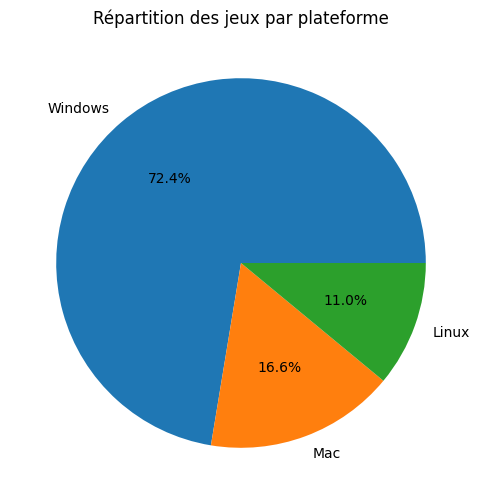

In [0]:
# Graphique camembert : répartition des jeux par plateforme
row = df_platform_totals.collect()[0]  # Récupération de la seule ligne du résultat

windows_count = row[0]
mac_count = row[1]
linux_count = row[2]

import matplotlib.pyplot as plt

labels = ["Windows", "Mac", "Linux"]
values = [windows_count, mac_count, linux_count]

plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Répartition des jeux par plateforme")
plt.show()

## Certains genres sont-ils préférentiellement disponibles sur certaines plateformes ?

In [0]:
from pyspark.sql.functions import col, split, explode, trim

df_flat = df.select("data.*")

# Aplatissement et explosion des genres
df_genre = df_flat.filter((col("genre").isNotNull()) & (col("genre") != ""))
df_genre_split = df_genre.withColumn("genre_indiv", explode(split(col("genre"), ",")))
df_genre_trimmed = df_genre_split.withColumn("genre_indiv", trim(col("genre_indiv")))

# Extraction des plateformes pour chaque ligne de genre
df_genre_platform = df_genre_trimmed.select(
    "genre_indiv",
    col("platforms.windows").alias("windows"),
    col("platforms.mac").alias("mac"),
    col("platforms.linux").alias("linux")
)

In [0]:
from pyspark.sql.functions import col

# Conversion des booléens en entiers pour permettre la somme
df_genre_platform_int = df_genre_platform.select(
    col("genre_indiv"),
    col("windows").cast("int").alias("windows_int"),
    col("mac").cast("int").alias("mac_int"),
    col("linux").cast("int").alias("linux_int")
)

# Agrégation : nombre de jeux disponibles par plateforme pour chaque genre
df_platform_stats = df_genre_platform_int.groupBy("genre_indiv").agg(
    {"windows_int": "sum", "mac_int": "sum", "linux_int": "sum"}
).withColumnRenamed("sum(windows_int)", "nb_windows") \
 .withColumnRenamed("sum(mac_int)", "nb_mac") \
 .withColumnRenamed("sum(linux_int)", "nb_linux")

# Tri par disponibilité Windows décroissante
df_platform_stats_sorted = df_platform_stats.orderBy(col("nb_windows").desc())

df_platform_stats_sorted.show(20, truncate=False)

+---------------------+-------------+---------+-----------+
|genre_indiv          |windows_count|mac_count|linux_count|
+---------------------+-------------+---------+-----------+
|Indie                |39676        |9935     |6978       |
|Action               |23755        |4564     |3379       |
|Casual               |22082        |5130     |3305       |
|Adventure            |21427        |5039     |3302       |
|Strategy             |10892        |3005     |1826       |
|Simulation           |10832        |2439     |1532       |
|RPG                  |9533         |2248     |1524       |
|Early Access         |6145         |900      |632        |
|Free to Play         |3391         |845      |474        |
|Sports               |2665         |506      |287        |
|Racing               |2154         |424      |304        |
|Massively Multiplayer|1459         |270      |164        |
|Utilities            |681          |102      |49         |
|Design & Illustration|405          |100

In [0]:
# Affichage Databricks du croisement genres × plateformes (top 20 genres)
df_platform_stats_top20 = df_platform_stats_sorted.limit(20)
display(df_platform_stats_top20)

genre_indiv,windows_count,mac_count,linux_count
Indie,39676,9935,6978
Action,23755,4564,3379
Casual,22082,5130,3305
Adventure,21427,5039,3302
Strategy,10892,3005,1826
Simulation,10832,2439,1532
RPG,9533,2248,1524
Early Access,6145,900,632
Free to Play,3391,845,474
Sports,2665,506,287


La répartition des plateformes est assez cohérente selon les genres : la grande majorité des jeux est disponible sur Windows, tandis que la prise en charge de Mac et Linux reste limitée et secondaire.

## Conclusions

L'étude détaillée du catalogue Steam met en lumière plusieurs facteurs déterminants pour les éditeurs. Le succès d'un jeu ne repose pas uniquement sur son appartenance à un genre populaire ou sur un grand nombre d'avis. Même si les catégories Action, Indie et Adventure dominent en volume, elles n'assurent ni forte rentabilité ni excellente réception critique. Les performances financières les plus solides se retrouvent souvent dans des genres capables d'allier attractivité large et prix plus élevés, notamment les RPG et les jeux de stratégie, soutenus par un fort engagement des joueurs.

Sur le plan technique, Windows s'impose comme la plateforme principale, tandis que Mac et Linux demeurent complémentaires. Le choix de la période de lancement influence également la visibilité et la performance commerciale. Enfin, l'analyse révèle une forte concentration des revenus entre les mains d'un nombre restreint d'éditeurs majeurs, laissant la majorité des studios avec des parts de marché limitées.